In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [17]:
dataset=pd.read_csv("car data.csv")
print(dataset.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [18]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [19]:
dataset['Car_Age'] = 2026 - dataset['Year']
dataset.drop(['Car_Name', 'Year'], axis=1, inplace=True)

In [20]:
numeric_cols = ['Present_Price', 'Kms_Driven', 'Owner']
for col in numeric_cols:
    dataset[col] = dataset[col].fillna(dataset[col].median())

cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
for col in cat_cols:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

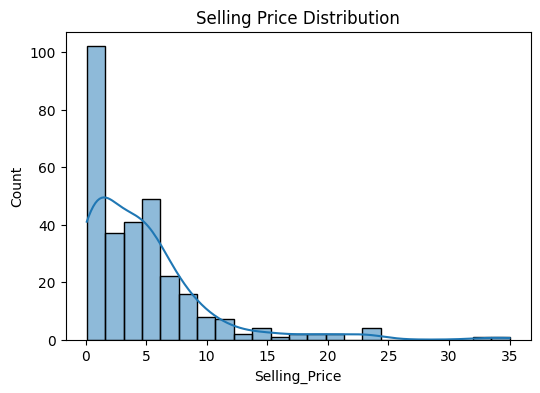

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(dataset['Selling_Price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

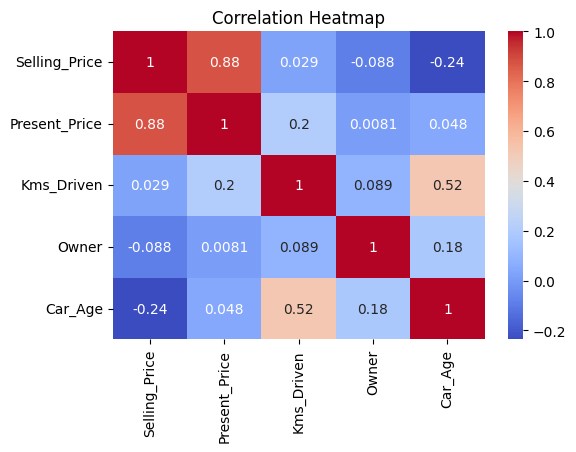

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(dataset.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

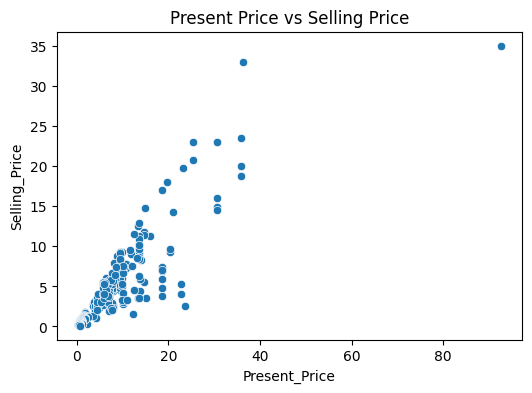

In [23]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=dataset['Present_Price'], y=dataset['Selling_Price'])
plt.title("Present Price vs Selling Price")
plt.show()

In [24]:
x = dataset.drop('Selling_Price', axis=1)
y = dataset['Selling_Price']

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), cat_cols)
    ],
    remainder='passthrough'
)

x = np.array(ct.fit_transform(x))
print(x)

[[0.0000e+00 1.0000e+00 0.0000e+00 ... 2.7000e+04 0.0000e+00 1.2000e+01]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 4.3000e+04 0.0000e+00 1.3000e+01]
 [0.0000e+00 1.0000e+00 0.0000e+00 ... 6.9000e+03 0.0000e+00 9.0000e+00]
 ...
 [0.0000e+00 1.0000e+00 0.0000e+00 ... 8.7934e+04 0.0000e+00 1.7000e+01]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 9.0000e+03 0.0000e+00 9.0000e+00]
 [0.0000e+00 1.0000e+00 0.0000e+00 ... 5.4640e+03 0.0000e+00 1.0000e+01]]


In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=2)

In [27]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(x_train,y_train)
y_pred_lin=lin_reg.predict(x_test)

In [28]:
from sklearn.tree import DecisionTreeRegressor
des_tree=DecisionTreeRegressor(random_state=42)
des_tree.fit(x_train,y_train)
y_pred_tree=des_tree.predict(x_test)

In [29]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=500, random_state=42)
rf_reg.fit(x_train, y_train)
y_pred_rf = rf_reg.predict(x_test)

In [30]:
from sklearn.preprocessing import PolynomialFeatures
poly_ob = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly_ob.fit_transform(x_train)
x_test_poly = poly_ob.transform(x_test)

poly_reg = LinearRegression()
poly_reg.fit(x_train_poly, y_train)
y_pred_poly = poly_reg.predict(x_test_poly)

In [31]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

models = {
    "Linear Regression": y_pred_lin,
    "Polynomial Regression": y_pred_poly,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf
}

results = []
for name, y_pred in models.items():
    results.append({
        'Model': name,
        'R2': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    })
df_results = pd.DataFrame(results)
print(df_results.sort_values(by='R2', ascending=False))

                   Model        R2      RMSE       MAE
3          Random Forest  0.961514  0.840744  0.489469
1  Polynomial Regression  0.955400  0.905067  0.566193
2          Decision Tree  0.928820  1.143382  0.624098
0      Linear Regression  0.850233  1.658520  1.245357


In [33]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_reg, x, y, cv=kf, scoring='r2')
print("CV Scores:", cv_scores)
print("CV Mean:", cv_scores.mean())
print("CV Std:", cv_scores.std())

CV Scores: [0.96020104 0.906477   0.89463563 0.90106498 0.94765966]
CV Mean: 0.9220076616080263
CV Std: 0.026630002372470103


In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 500}


In [35]:
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(x_test)

print("Final R2:", r2_score(y_test, y_pred_best))

Final R2: 0.9621085818150027


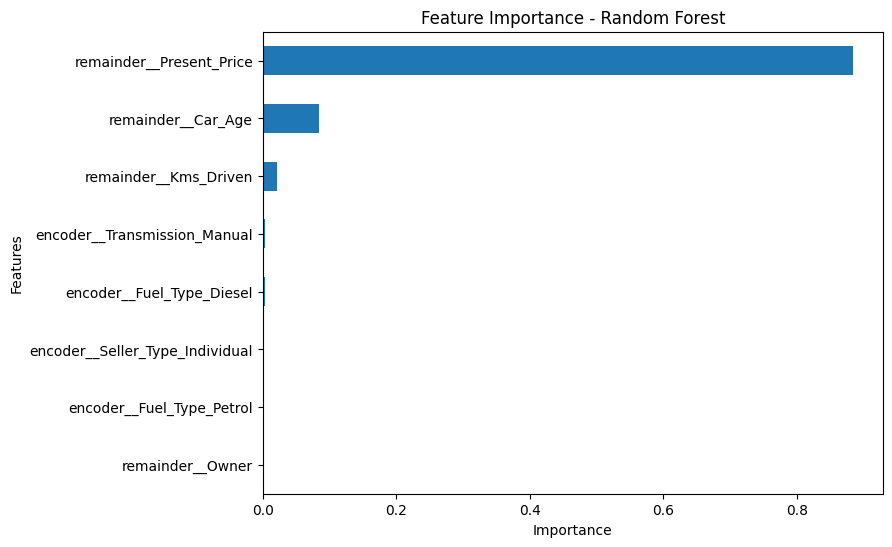

In [37]:
importances = best_rf.feature_importances_
feat_names = ct.get_feature_names_out()
feat_importance = pd.Series(importances, index=feat_names)

plt.figure(figsize=(8,6))
feat_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

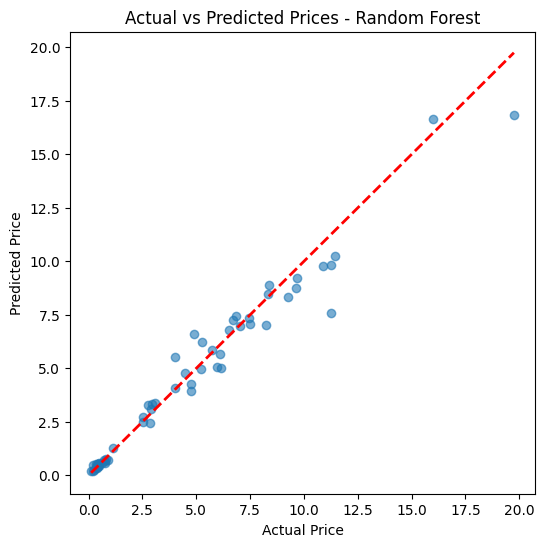

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices - Random Forest")
plt.show()

In [39]:
print("Top 3 Features affecting Selling Price:")
print(feat_importance.sort_values(ascending=False).head(3))

Top 3 Features affecting Selling Price:
remainder__Present_Price    0.884233
remainder__Car_Age          0.083518
remainder__Kms_Driven       0.020953
dtype: float64
